# Data Analytics — Train the Trainer
## Student Copy

**10 Days · 80 Hours · Google Colaboratory**
Aligned to the TESDA Competency Standards for Data Analytics Level III.

---
### How each day is structured

| Time | Segment |
|---|---|
| 8:00 – 9:00 | Lecture 1 |
| 9:00 – 10:00 | Hands-On 1 |
| 10:00 – 10:10 | Break |
| 10:10 – 10:40 | Analysis and Discussion 1 |
| 10:40 – 11:40 | Lecture 2 |
| 11:40 – 12:40 | Hands-On 2 |
| 12:40 – 1:40 | Lunch |
| 1:40 – 2:10 | Analysis and Discussion 2 |
| 2:10 – 3:10 | Lecture 3 |
| 3:10 – 4:10 | Hands-On 3 |
| 4:10 – 4:20 | Break |
| 4:20 – 4:50 | Analysis and Discussion 3 |
| 4:50 – 5:00 | Wrap-Up |

Fill in the cells marked `# your code here`. Your instructor has the answer key.

---
*Prepared by Nina Comia for the Department of Information and Communications Technology (DICT).*

## Setup — Run This First (Every Session)
Colab clears files when the runtime disconnects. If your variables vanish, run this cell again.

In [3]:
# ============================================================
# SETUP — run this cell first, every session.
# Creates the two course data files inside ./data/
#   service_requests.csv   (1,222 rows, with deliberate defects)
#   regional_offices.json  (9 offices, nested structure)
# ============================================================
import pandas as pd, numpy as np, json, random, os

np.random.seed(2026); random.seed(2026)
os.makedirs("data", exist_ok=True)

REGIONS = ["NCR", "Region III", "Region IV-A", "Region VI", "Region VII", "Region XI"]
OFFICES = {"NCR": ["DICT-NCR-01", "DICT-NCR-02"], "Region III": ["DICT-R3-01"],
           "Region IV-A": ["DICT-R4A-01", "DICT-R4A-02"], "Region VI": ["DICT-R6-01"],
           "Region VII": ["DICT-R7-01", "DICT-R7-02"], "Region XI": ["DICT-R11-01"]}
SERVICES = ["Free WiFi Installation", "Digital Literacy Training", "Business Permit Assistance",
            "ICT Equipment Request", "Cybersecurity Advisory", "eGov App Support"]
CHANNELS = ["Walk-in", "Online Portal", "Email", "Hotline", "Mobile App"]
STATUS = ["Resolved", "Pending", "Escalated", "Closed - No Action"]
AGE_GROUPS = ["18-24", "25-34", "35-44", "45-54", "55+"]

dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")
rows = []
for i in range(1, 1201):
    region = random.choice(REGIONS)
    status = random.choices(STATUS, weights=[62, 20, 12, 6])[0]
    rows.append({
        "request_id": f"SR-2025-{i:05d}",
        "date_filed": random.choice(dates),
        "region": region,
        "office_code": random.choice(OFFICES[region]),
        "service_type": random.choice(SERVICES),
        "channel": random.choices(CHANNELS, weights=[30, 25, 15, 15, 15])[0],
        "status": status,
        "days_to_resolve": max(0, int(np.random.lognormal(1.6, 0.75))) if status in ("Resolved", "Closed - No Action") else np.nan,
        "satisfaction_rating": random.choice([1,2,3,4,5]) if status == "Resolved" else np.nan,
        "citizen_age_group": random.choice(AGE_GROUPS),
        "processing_fee": float(random.choice([0, 0, 0, 50, 100, 150, 200])),
    })
df = pd.DataFrame(rows)

# Inject realistic data-quality defects (used in the Day 5 cleaning lessons)
d = df.copy()
_ncr = d.index[d["region"] == "NCR"]
d.loc[pd.Index(np.random.RandomState(1).choice(_ncr, 40, replace=False)), "region"] = " ncr "
d.loc[d.sample(25, random_state=2).index, "service_type"] = "Free Wifi Installation"
d.loc[d.sample(30, random_state=3).index, "citizen_age_group"] = np.nan
d.loc[d.sample(18, random_state=4).index, "processing_fee"] = np.nan
d.loc[d.sample(8,  random_state=5).index, "days_to_resolve"] = 999
d = pd.concat([d, d.sample(22, random_state=6)])
d["date_filed"] = d["date_filed"].astype(str)
_mix = d.sample(60, random_state=7).index
d.loc[_mix, "date_filed"] = pd.to_datetime(d.loc[_mix, "date_filed"]).dt.strftime("%m/%d/%Y")
d = d.sample(frac=1, random_state=8).reset_index(drop=True)
d.to_csv("data/service_requests.csv", index=False)

CITIES = {"NCR": "Quezon City", "Region III": "San Fernando", "Region IV-A": "Calamba",
          "Region VI": "Iloilo City", "Region VII": "Cebu City", "Region XI": "Davao City"}
offices = []
for region, codes in OFFICES.items():
    for c_ in codes:
        offices.append({
            "office_code": c_,
            "office_name": f"DICT Field Office {c_.split('-')[-1]} - {region}",
            "location": {"region": region, "city": CITIES[region],
                         "coordinates": {"lat": round(random.uniform(6.0, 16.5), 4),
                                         "lon": round(random.uniform(120.0, 126.0), 4)}},
            "staff_count": random.randint(8, 45),
            "year_established": random.randint(2012, 2022),
            "annual_budget_php": random.randrange(2_000_000, 12_000_000, 250_000),
            "services_offered": random.sample(SERVICES, k=random.randint(3, 6)),
            "is_active": random.random() > 0.1,
        })
with open("data/regional_offices.json", "w") as f:
    json.dump({"agency": "Department of Information and Communications Technology",
               "dataset": "Regional Field Office Master Data", "as_of": "2025-12-31",
               "record_count": len(offices), "offices": offices}, f, indent=2)

print("Setup complete. Files in ./data/:")
for fn in sorted(os.listdir("data")):
    print("   ", fn)
print("\nCSV rows:", len(d), "| Offices:", len(offices))

Setup complete. Files in ./data/:
    regional_offices.json
    service_requests.csv

CSV rows: 1222 | Offices: 9


---
# Day 5 — Preparing Data Sets II: Cleaning and Data Integrity
*TESDA alignment: Prepare data sets (clean data, filter data)*

## Lecture 1 — Profile Before You Fix

The professional habit is diagnose, then treat. Never edit data you have not profiled.

**The profiling checklist:**
1. Shape and dtypes. Does the row count match what you expected?
2. Missing values per column. Which columns, and how many?
3. Duplicate rows. Full duplicates and duplicate keys are different problems.
4. Unique values in every categorical column. This is where inconsistent entries hide.
5. Ranges of numeric columns. Minimums and maximums reveal impossible values.

**Back up the raw file before cleaning.** Work on a copy. Cleaning must be written as code so it can be re-run and audited, never as manual edits.

In [4]:
import pandas as pd
raw = pd.read_csv("data/service_requests.csv")

print("Shape:", raw.shape)
print("\nMissing values:")
print(raw.isna().sum()[raw.isna().sum() > 0])
print("\nFull duplicate rows:", raw.duplicated().sum())
print("Duplicate request_ids:", raw["request_id"].duplicated().sum())
print("\nRegion values:", raw["region"].unique())
print("\ndays_to_resolve range:", raw["days_to_resolve"].min(), "to", raw["days_to_resolve"].max())

Shape: (1222, 11)

Missing values:
days_to_resolve        398
satisfaction_rating    467
citizen_age_group       31
processing_fee          18
dtype: int64

Full duplicate rows: 22
Duplicate request_ids: 22

Region values: ['Region III' 'Region VI' 'Region XI' 'Region VII' ' ncr ' 'NCR'
 'Region IV-A']

days_to_resolve range: 0.0 to 999.0


### Hands-On 1 — Profile the Raw Data

1. Load the raw CSV as `raw`. Store the number of full duplicate rows in `dup_count`.
2. Build `missing_report` — a Series of missing counts per column, showing only columns that have missing values.
3. For each of `region`, `service_type`, and `status`, print the unique values. Store the number of unique `region` values in `region_variants`.
4. Store the maximum of `days_to_resolve` in `max_days`. State in a comment whether you believe it is real.

In [5]:
import pandas as pd

# Load the raw CSV as `raw`
raw = pd.read_csv("data/service_requests.csv")


# 1. Count the number of full duplicate rows
# `.duplicated()` identifies duplicate rows, and `.sum()` counts them.
dup_count = raw.duplicated().sum()


# 2. Build `missing_report`
# Count missing values per column, then keep only columns with missing values.
missing_report = raw.isna().sum()[raw.isna().sum() > 0]


# 3. Print the unique values for region, service_type, and status.
# `.unique()` gives the actual unique values for each column.
print("Region values:", raw["region"].unique())
print("Service type values:", raw["service_type"].unique())
print("Status values:", raw["status"].unique())

# Store the NUMBER of unique region values in `region_variants`.
# `.nunique()` counts the unique values.
region_variants = raw["region"].nunique()


# 4. Store the maximum value of days_to_resolve.
max_days = raw["days_to_resolve"].max()

# The maximum of 999 is probably not real.
# It was intentionally inserted as a data-quality defect in the setup.
# A value of 999 days is unusually high for a service request.
print("Max days:", max_days)


# Display the results
print("Duplicates:", dup_count)
print("\nMissing values:")
print(missing_report)
print("\nRegion variants:", region_variants)
print("Max days:", max_days)


Region values: ['Region III' 'Region VI' 'Region XI' 'Region VII' ' ncr ' 'NCR'
 'Region IV-A']
Service type values: ['ICT Equipment Request' 'Cybersecurity Advisory' 'Free WiFi Installation'
 'Business Permit Assistance' 'eGov App Support'
 'Digital Literacy Training' 'Free Wifi Installation']
Status values: ['Resolved' 'Pending' 'Escalated' 'Closed - No Action']
Max days: 999.0
Duplicates: 22

Missing values:
days_to_resolve        398
satisfaction_rating    467
citizen_age_group       31
processing_fee          18
dtype: int64

Region variants: 7
Max days: 999.0


**Analysis and Discussion 1**

- Two columns have many missing values. Which one is a data quality defect and which is expected behavior? How do you tell?
- The maximum resolution time is 999. What are three ways a number like that gets into a system?
- You have 22 duplicate rows. Before deleting them, what should you check?

## Lecture 2 — Missing Values, Duplicates, and Categories

**Missing values.** Three options, each a decision you must be able to defend:
- *Drop* the rows. Safe only if few and not systematically different from the rest.
- *Fill* with a value. Median for skewed numbers, mode for categories, or a literal `"Unknown"` label.
- *Flag* and keep. Add a boolean column and leave the value missing. Often the most honest choice.

**Duplicates.** `drop_duplicates()` removes full duplicates. `drop_duplicates(subset=["request_id"])` removes repeated keys, keeping the first. Decide which one your data needs.

**Inconsistent categories.** `.str.strip()` removes whitespace, `.str.upper()` or `.str.title()` standardizes case, and `.replace()` maps known variants to a canonical value.

**Mixed date formats.** `pd.to_datetime(col, format="mixed")` handles more than one layout in the same column.

In [6]:
import pandas as pd
raw = pd.read_csv("data/service_requests.csv")
clean = raw.copy()                        # never modify the raw object

clean = clean.drop_duplicates()
clean["region"] = clean["region"].str.strip().str.upper()
clean["service_type"] = clean["service_type"].replace(
    {"Free Wifi Installation": "Free WiFi Installation"})
clean["date_filed"] = pd.to_datetime(clean["date_filed"], format="mixed")

print("Rows:", len(raw), "->", len(clean))
print("Regions:", sorted(clean["region"].unique()))
print("Service types:", clean["service_type"].nunique())

Rows: 1222 -> 1200
Regions: ['NCR', 'REGION III', 'REGION IV-A', 'REGION VI', 'REGION VII', 'REGION XI']
Service types: 6


Missing values before imputation:
Col_A    245
Col_B    262
Col_C    252
Col_D    258
dtype: int64

Missing values in the first completed dataset:
Col_A    0
Col_B    0
Col_C    0
Col_D    0
dtype: int64

Original Col_A at row 0: nan
Five imputed estimates: [np.float64(-0.11251249794726859), np.float64(-1.6785135829444306), np.float64(0.6111224383594912), np.float64(-0.3557114361081896), np.float64(-0.8287962359337521)]


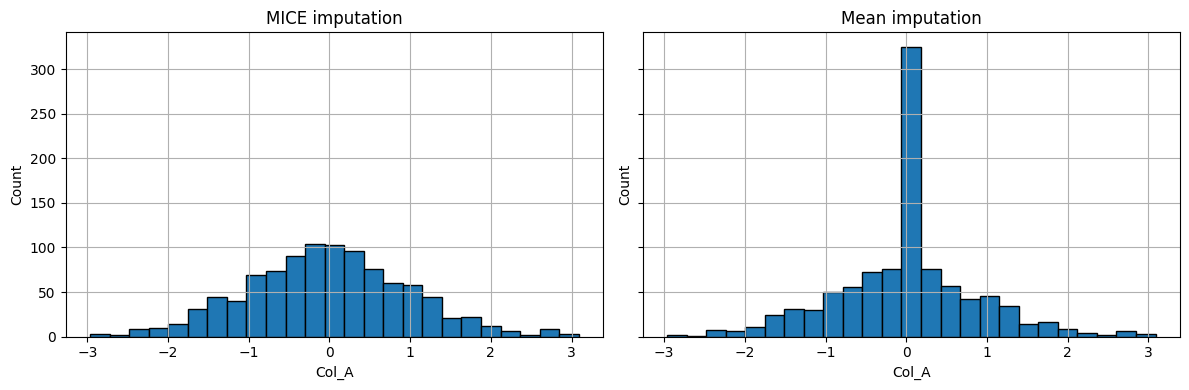

In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

# 1. Generate data with approximately 25% missing values
rows, cols = 1000, 4
rng = np.random.default_rng(seed=42)

data = rng.standard_normal(size=(rows, cols))  # Standard normal values
nan_mask = rng.random(size=data.shape) < 0.25
data[nan_mask] = np.nan

df = pd.DataFrame(data, columns=["Col_A", "Col_B", "Col_C", "Col_D"])

print("Missing values before imputation:")
print(df.isna().sum())

# 2. Run MICE five times to obtain five completed datasets
imputed_datasets = []

for seed in range(5):
    imputer = IterativeImputer(
        max_iter=10,
        sample_posterior=True,
        random_state=seed
    )

    completed = pd.DataFrame(
        imputer.fit_transform(df),
        columns=df.columns,
        index=df.index
    )
    imputed_datasets.append(completed)

# 3. Inspect one result and compare estimates for a missing cell
print("\nMissing values in the first completed dataset:")
print(imputed_datasets[0].isna().sum())

missing_row = df.index[df["Col_A"].isna()][0]
print(f"\nOriginal Col_A at row {missing_row}:", df.loc[missing_row, "Col_A"])
print("Five imputed estimates:", [
    completed.loc[missing_row, "Col_A"]
    for completed in imputed_datasets
])

# Confirm that observed values were preserved
observed = df.notna()
assert all(
    completed.where(observed).equals(df.where(observed))
    for completed in imputed_datasets
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

completed["Col_A"].hist(ax=axes[0], bins=25, edgecolor="black")
axes[0].set_title("MICE imputation")

df["Col_A"].fillna(df["Col_A"].mean()).hist(
    ax=axes[1], bins=25, edgecolor="black"
)
axes[1].set_title("Mean imputation")

for ax in axes:
    ax.set_xlabel("Col_A")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Hands-On 2 — Clean It

Build `clean` from `raw`, in this order:

1. Drop full duplicate rows.
2. Standardize `region`: strip whitespace, uppercase.
3. Fix the `service_type` spelling variant so there are exactly 6 service types.
4. Parse `date_filed` with `format="mixed"`.
5. Fill missing `citizen_age_group` with the string `"Unknown"`.
6. Fill missing `processing_fee` with the **median** fee, and add a boolean column `fee_was_missing` flagging which rows you filled.

Print the final shape, the region list, and the service type count.

In [15]:
import pandas as pd

raw = pd.read_csv("data/service_requests.csv")
clean = raw.copy()


# 1. Drop full duplicate rows
clean = clean.drop_duplicates()


# 2. Standardize region
# Remove leading/trailing whitespace and convert all values to uppercase.
clean["region"] = clean["region"].str.strip().str.upper()


# 3. Fix the service_type spelling variant
# "Free Wifi Installation" → "Free WiFi Installation"
# This should leave exactly 6 service types.
clean["service_type"] = clean["service_type"].replace(
    {"Free Wifi Installation": "Free WiFi Installation"}
)


# 4. Parse date_filed
# format="mixed" allows the column to contain different date formats.
clean["date_filed"] = pd.to_datetime(
    clean["date_filed"],
    format="mixed"
)


# 5. Fill missing citizen_age_group values with "Unknown"
clean["citizen_age_group"] = clean["citizen_age_group"].fillna("Unknown")


# 6. Fill missing processing_fee with the median
# First create a boolean flag so we know which rows originally had missing fees.
clean["fee_was_missing"] = clean["processing_fee"].isna()

# Calculate the median from the existing non-missing fees
# and use it to fill the missing values.
clean["processing_fee"] = clean["processing_fee"].fillna(
    clean["processing_fee"].median()
)


# Final checks
print("Shape:", clean.shape)
print("Regions:", sorted(clean["region"].unique()))
print("Service type count:", clean["service_type"].nunique())

print("Citizen Age Group:", clean["citizen_age_group"].unique())
print("fee_was_missing:", clean["fee_was_missing"].sum())
print("Missing processing_fee:", clean["processing_fee"].isna().sum())


Shape: (1200, 12)
Regions: ['NCR', 'REGION III', 'REGION IV-A', 'REGION VI', 'REGION VII', 'REGION XI']
Service type count: 6
Citizen Age Group: ['55+' '35-44' '18-24' '25-34' '45-54' 'Unknown']
fee_was_missing: 18
Missing processing_fee: 0


**Analysis and Discussion 2**

- You filled missing fees with the median. What are the consequences if those 18 requests were genuinely free?
- Why create `fee_was_missing` at all? Who benefits from it later?
- Would you fill missing `days_to_resolve` the same way? Explain why not.

## Lecture 3 — Outliers, Integrity, and Versioning

**Outliers.** The IQR rule gives a defensible threshold:

```
Q1, Q3 = col.quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
```

An outlier is not automatically an error. Investigate before deleting. A genuinely slow request tells you something; a sentinel value tells you nothing.

**Sentinel values** are placeholders that look like data: 999, -1, 0 for "no answer", 1900-01-01. Find them by looking at the extremes of every numeric column.

**Data integrity** means the relationships hold: resolved requests should have a resolution time, dates should fall in the expected range, and every office code should exist in the master file.

**Versioning.** Save the cleaned data under a dated or versioned name and keep the raw file untouched. Anyone should be able to re-run your cleaning code and get the same result.

In [9]:

((clean["days_to_resolve"]>upper) | (clean["days_to_resolve"]<lower))

,days_to_resolve
0,False
1,False
2,False
3,False
4,False
...,...
1217,False
1218,False
1219,False
1220,False


In [10]:
import pandas as pd
clean = pd.read_csv("data/service_requests.csv").drop_duplicates()

col = clean["days_to_resolve"]
q1, q3 = col.quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print(f"Q1={q1}  Q3={q3}  upper fence={upper:.1f} lower fence={lower:.1f}")
print("Values above fence:", (col > upper).sum())
print("Values below fence:", (col < lower).sum())
print("Exactly 999:", (col == 999).sum(), "<- sentinel, not a real outlier")

clean["is_outlier_days_to_resolve"] = (clean["days_to_resolve"]>upper) | (clean["days_to_resolve"]<lower)
clean["is_outlier_days_to_resolve"].value_counts()

Q1=3.0  Q3=9.0  upper fence=18.0 lower fence=-6.0
Values above fence: 41
Values below fence: 0
Exactly 999: 8 <- sentinel, not a real outlier


,count
is_outlier_days_to_resolve,
False,1159
True,41


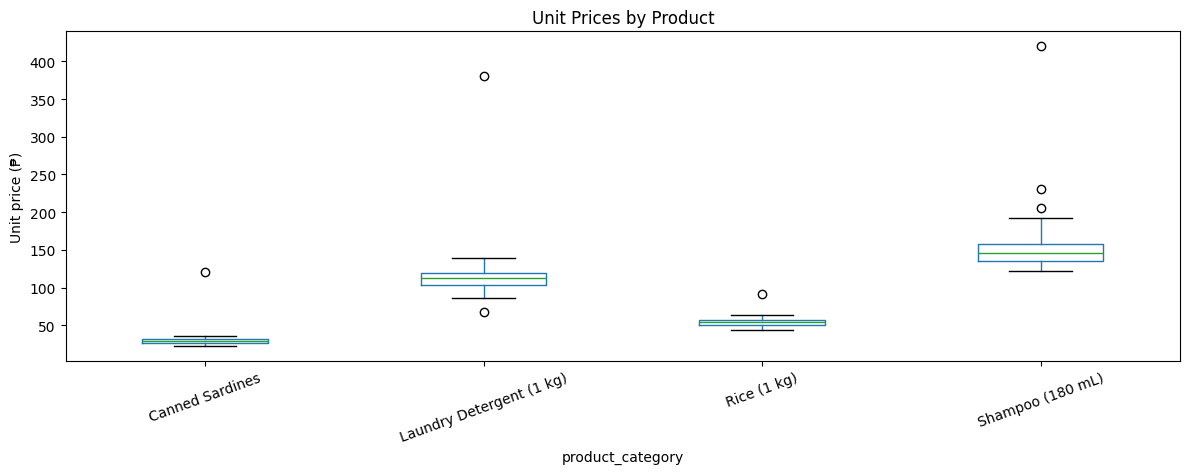

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/imjbmkz/sample_datasets/refs/heads/main/ph_retail_prices_histogram_boxplot_demo.csv")

# # 1. Histogram: one panel per product category
# df.hist(
#     column="unit_price_php",
#     by="product_category",
#     bins=15,
#     figsize=(12, 8),
#     layout=(2, 2),
#     edgecolor="black"
# )
# plt.suptitle("Distribution of Unit Prices by Product", y=1.02)
# plt.tight_layout()
# plt.show()

# 2. Box plot: compare products side by side
df.boxplot(
    column="unit_price_php",
    by="product_category",
    figsize=(12, 5),
    grid=False,
    rot=20
)
plt.title("Unit Prices by Product")
plt.suptitle("")  # Remove pandas' automatic subtitle
plt.ylabel("Unit price (₱)")
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from scipy.stats.mstats import winsorize

# Sample data with extreme values/outliers
data = df["unit_price_php"]

# Cap 10% from the bottom and 10% from the top
capped_data = winsorize(data, limits=[0.10, 0.10])

print("Original:", data.min(), data.max())
print("Capped:  ", capped_data.min(),capped_data.max())


Original: 27.94 149.56
Capped:   27.94 149.56


### Hands-On 3 — Outliers and Versioned Output

Continue from your `clean` DataFrame.

1. Compute the IQR upper fence for `days_to_resolve`. Store it in `upper_fence`.
2. Count values above the fence (`outlier_count`) and count values exactly equal to 999 (`sentinel_count`).
3. Replace the 999 values with missing (`np.nan`), since they are placeholders and not measurements.
4. Run an integrity check: store in `integrity` a dictionary with keys `resolved_have_days` (True if every Resolved row now has a non-null days_to_resolve), `dates_in_2025` (True if all dates fall in 2025), and `no_dup_ids` (True if request_id is unique).
5. Save as `data/service_requests_clean_v1.csv`.

In [16]:
import pandas as pd
import numpy as np

raw = pd.read_csv("data/service_requests.csv")

clean = raw.drop_duplicates().copy()
clean["region"] = clean["region"].str.strip().str.upper()
clean["service_type"] = clean["service_type"].replace(
    {"Free Wifi Installation": "Free WiFi Installation"}
)
clean["date_filed"] = pd.to_datetime(clean["date_filed"], format="mixed")


# 1. Compute the IQR upper fence for days_to_resolve
col = clean["days_to_resolve"]

q1, q3 = col.quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr


# 2. Count values above the upper fence and values exactly equal to 999
outlier_count = (col > upper_fence).sum()
sentinel_count = (col == 999).sum()


# 3. Replace the sentinel value 999 with missing values
# 999 is a placeholder, not a real resolution-time measurement.
clean["days_to_resolve"] = clean["days_to_resolve"].replace(999, np.nan)


# 4. Run integrity checks
integrity = {
    "resolved_have_days": clean.loc[
        clean["status"] == "Resolved", "days_to_resolve"
    ].notna().all(),

    "dates_in_2025": (
        clean["date_filed"].dt.year == 2025
    ).all(),

    "no_dup_ids": clean["request_id"].is_unique
}


# 5. Save the cleaned data as a versioned output
clean.to_csv("data/service_requests_clean_v1.csv", index=False)


# Display results
print("Upper fence:", upper_fence)
print("Outlier count:", outlier_count)
print("Sentinel count:", sentinel_count)
print("Integrity:", integrity)
print("Saved: data/service_requests_clean_v1.csv")


Upper fence: 18.0
Outlier count: 41
Sentinel count: 8
Integrity: {'resolved_have_days': np.False_, 'dates_in_2025': np.True_, 'no_dup_ids': True}
Saved: data/service_requests_clean_v1.csv


**Analysis and Discussion 3**

- One integrity check fails after cleaning. Is your data now worse, or more honest?
- The IQR flagged more values than just the 999s. How would you decide which of those are real?
- Why save as `_v1` instead of overwriting the source file? What does that buy you three months from now?

## Take-home activity

### Scenario

You have received a simulated file of 5,000 Philippine retail orders. Your task is to inspect its quality and prepare a processed version for analysis in Google Colab. The data contains intentional missing values, different spellings of the same Philippine region, inconsistent product categories, and unusual numeric values.

Input: ph_retail_orders_raw_v1.csv
Tools: Google Colab and Python/pandas
Output: A cleaned CSV and a short cleaning log

Each row represents one order. order_total_php was recorded when the order was created; do not assume it is correct after investigating the other fields. The region names should be standardized against the Philippine Standard Geographic Code (PSGC). Some source labels are abbreviations or alternate spellings of valid regions; some region values are blank.

### Tasks

1. Use the code below to read the data
2. Profile the data
- Report the following before making changes:
- Column names, data types, and a sample of records.
- Missing-value count and percentage for each column.
- Duplicate order_id values and fully duplicated rows, if any.
- Distinct region and product category labels, including differences in spelling, case, or spaces.
- Minimum, median, maximum, and selected percentiles for quantity, unit_price_php, order_total_php, and delivery_days.
- Values that appear impossible or require investigation, such as negative numbers, zero quantity, placeholder numbers, or exceptionally large values.
3. Handle missing data
- Choose and document a treatment for missing values in each affected column. Demonstrate and explain these three approaches where appropriate:
- Drop: Remove a record when a required field is missing and its value cannot be recovered.
- Impute: Fill a missing numeric value with a justified statistic, such as the median within a suitable product category.
- Flag and keep: Retain an unresolved record and add a Boolean indicator such as region_missing or price_missing.
- Convert placeholder values such as -1 or 9999 to missing only after checking the field and explaining why the value is a placeholder. Do not replace a missing region with a guessed region.
4. Standardize labels
- Remove unwanted leading or trailing spaces and normalize capitalization where useful.
- Map region abbreviations, alternate names, and spelling variants to the appropriate PSGC region names. Confirm that each nonmissing processed region belongs to the list of 18 PSGC regions.
- Standardize product category labels so that different spellings of the same category use one name.
- Preserve the original region value in region_raw so your mapping can be reviewed.

PSGC region reference: https://psa.gov.ph/classification/psgc/regions

5. Investigate outliers and integrity
- Use a simple rule or visual, such as IQR bounds, percentiles, a histogram, or a box plot, to identify unusually large prices, quantities, totals, and delivery times.
- Examine the flagged records. Explain which values are impossible, which might be legitimate, and what you did with each group. Do not delete all statistical outliers automatically.
- Check whether order_total_php agrees with quantity × unit_price_php where both inputs are valid. Flag discrepancies and document how you handled them.
- Check that each processed order_id is unique and that numeric fields meet the rules you chose for valid orders.

6. Save and summarize
- Export your processed data as ph_retail_orders_processed_v1.csv.
- Create a brief cleaning log containing: each rule, why you chose it, the number of rows it affected, and any unresolved issues.
- Re-run the key profiling checks on the processed file and compare the results with the raw file. State the final row count and any rows excluded from analysis.

### Submit
- Your Google Colab notebook, with code cells that run from top to bottom.
- ph_retail_orders_processed_v1.csv.
- Your cleaning log (a Markdown cell in the notebook is sufficient).
- Your choices may differ from another

In [14]:
import pandas as pd
import numpy as np

# ============================================================
# 1. LOAD THE RAW DATA
# ============================================================

df_ph_retail = pd.read_csv(
    "https://raw.githubusercontent.com/imjbmkz/sample_datasets/refs/heads/main/ph_retail_orders_raw_v1.csv"
)

# Keep the original data unchanged.
raw = df_ph_retail.copy()

print("Shape:", raw.shape)
print("\nColumns:")
print(raw.columns.tolist())

print("\nData types:")
print(raw.dtypes)

print("\nSample:")
display(raw.head())


# ============================================================
# 2. PROFILE THE RAW DATA
# ============================================================

# Missing values: count and percentage
missing_count = raw.isna().sum()
missing_pct = (missing_count / len(raw) * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})

print("\nMissing values:")
display(missing_report)


# Duplicate checks
print("\nFully duplicated rows:",
      raw.duplicated().sum())

print("Duplicate order_id values:",
      raw["order_id"].duplicated().sum())


# Distinct region labels
print("\nDistinct region labels:")
print(sorted(raw["region"].dropna().astype(str).unique()))


# Distinct product categories
print("\nDistinct product categories:")
print(sorted(
    raw["product_category"]
    .dropna()
    .astype(str)
    .unique()
))


# Numeric profile
numeric_cols = [
    "quantity",
    "unit_price_php",
    "order_total_php",
    "delivery_days"
]

print("\nNumeric profile:")

profile = raw[numeric_cols].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
).T

display(profile)


# Check suspicious values
print("\nSuspicious numeric values:")

for col in numeric_cols:

    print(f"\n--- {col} ---")

    print("Negative:", (raw[col] < 0).sum())
    print("Zero:", (raw[col] == 0).sum())

    for value in [-1, 999, 9999, 999999]:
        count = (raw[col] == value).sum()

        if count > 0:
            print(f"{value}:", count)


# ============================================================
# 3. CREATE CLEAN COPY
# ============================================================

clean = raw.copy()


# ============================================================
# 4. REMOVE FULL DUPLICATES
# ============================================================

before = len(clean)

clean = clean.drop_duplicates()

full_duplicates_removed = before - len(clean)

print(
    "\nFull duplicate rows removed:",
    full_duplicates_removed
)


# ============================================================
# 5. PRESERVE ORIGINAL REGION
# ============================================================

# Keep the original value so the transformation can be audited.
clean["region_raw"] = clean["region"]


# ============================================================
# 6. STANDARDIZE REGION LABELS
# ============================================================

# First remove extra spaces and normalize case.
region_key = (
    clean["region"]
    .astype("string")
    .str.strip()
    .str.upper()
)


# Official PSGC region names used as the canonical values.
psgc_regions = [
    "National Capital Region (NCR)",
    "Cordillera Administrative Region (CAR)",
    "Region I (Ilocos Region)",
    "Region II (Cagayan Valley)",
    "Region III (Central Luzon)",
    "Region IV-A (CALABARZON)",
    "MIMAROPA Region",
    "Region V (Bicol Region)",
    "Region VI (Western Visayas)",
    "Negros Island Region (NIR)",
    "Region VII (Central Visayas)",
    "Region VIII (Eastern Visayas)",
    "Region IX (Zamboanga Peninsula)",
    "Region X (Northern Mindanao)",
    "Region XI (Davao Region)",
    "Region XII (SOCCSKSARGEN)",
    "Region XIII (Caraga)",
    "Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)"
]


# Map source abbreviations and alternate names to PSGC names.
region_map = {

    "NCR":
        "National Capital Region (NCR)",

    "NATIONAL CAPITAL REGION":
        "National Capital Region (NCR)",

    "CAR":
        "Cordillera Administrative Region (CAR)",

    "CORDILLERA ADMINISTRATIVE REGION":
        "Cordillera Administrative Region (CAR)",

    "REGION I":
        "Region I (Ilocos Region)",

    "REGION 1":
        "Region I (Ilocos Region)",

    "ILOCOS REGION":
        "Region I (Ilocos Region)",

    "REGION II":
        "Region II (Cagayan Valley)",

    "REGION 2":
        "Region II (Cagayan Valley)",

    "CAGAYAN VALLEY":
        "Region II (Cagayan Valley)",

    "REGION III":
        "Region III (Central Luzon)",

    "REGION 3":
        "Region III (Central Luzon)",

    "CENTRAL LUZON":
        "Region III (Central Luzon)",

    "REGION IV-A":
        "Region IV-A (CALABARZON)",

    "REGION IVA":
        "Region IV-A (CALABARZON)",

    "REGION 4A":
        "Region IV-A (CALABARZON)",

    "CALABARZON":
        "Region IV-A (CALABARZON)",

    "REGION IV-B":
        "MIMAROPA Region",

    "REGION IVB":
        "MIMAROPA Region",

    "REGION 4B":
        "MIMAROPA Region",

    "MIMAROPA":
        "MIMAROPA Region",

    "MIMAROPA REGION":
        "MIMAROPA Region",

    "REGION V":
        "Region V (Bicol Region)",

    "REGION 5":
        "Region V (Bicol Region)",

    "BICOL REGION":
        "Region V (Bicol Region)",

    "REGION VI":
        "Region VI (Western Visayas)",

    "REGION 6":
        "Region VI (Western Visayas)",

    "WESTERN VISAYAS":
        "Region VI (Western Visayas)",

    "W. VISAYAS":
        "Region VI (Western Visayas)",

    "NIR":
        "Negros Island Region (NIR)",

    "NEGROS ISLAND REGION":
        "Negros Island Region (NIR)",

    "REGION VII":
        "Region VII (Central Visayas)",

    "REGION 7":
        "Region VII (Central Visayas)",

    "CENTRAL VISAYAS":
        "Region VII (Central Visayas)",

    "REGION VIII":
        "Region VIII (Eastern Visayas)",

    "REGION 8":
        "Region VIII (Eastern Visayas)",

    "EASTERN VISAYAS":
        "Region VIII (Eastern Visayas)",

    "REGION IX":
        "Region IX (Zamboanga Peninsula)",

    "REGION 9":
        "Region IX (Zamboanga Peninsula)",

    "ZAMBOANGA PENINSULA":
        "Region IX (Zamboanga Peninsula)",

    "REGION X":
        "Region X (Northern Mindanao)",

    "REGION 10":
        "Region X (Northern Mindanao)",

    "NORTHERN MINDANAO":
        "Region X (Northern Mindanao)",

    "REGION XI":
        "Region XI (Davao Region)",

    "REGION 11":
        "Region XI (Davao Region)",

    "DAVAO REGION":
        "Region XI (Davao Region)",

    "REGION XII":
        "Region XII (SOCCSKSARGEN)",

    "REGION 12":
        "Region XII (SOCCSKSARGEN)",

    "SOCCSKSARGEN":
        "Region XII (SOCCSKSARGEN)",

    "REGION XIII":
        "Region XIII (Caraga)",

    "REGION 13":
        "Region XIII (Caraga)",

    "CARAGA":
        "Region XIII (Caraga)",

    "BARMM":
        "Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)",

    "BANGSAMORO":
        "Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)",

    "BANGSAMORO AUTONOMOUS REGION IN MUSLIM MINDANAO":
        "Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)"
}


# Apply the mapping.
clean["region"] = region_key.map(region_map)


# ============================================================
# 7. FLAG MISSING / UNRESOLVED REGIONS
# ============================================================

# Do not guess missing or invalid regions.
clean["region_missing"] = clean["region"].isna()

print("\nUnresolved region values:")

unresolved = clean.loc[
    clean["region"].isna(),
    "region_raw"
].value_counts(dropna=False)

print(unresolved)


# ============================================================
# 8. STANDARDIZE PRODUCT CATEGORIES
# ============================================================

# Remove extra spaces and normalize capitalization.
clean["product_category"] = (
    clean["product_category"]
    .astype("string")
    .str.strip()
    .str.title()
)

print("\nProduct categories after standardization:")
print(sorted(
    clean["product_category"]
    .dropna()
    .unique()
))


# ============================================================
# 9. HANDLE KNOWN PLACEHOLDERS
# ============================================================

# 9999 appears in unit_price_php and is clearly inconsistent
# with the normal price range.
#
# -1 also appears in unit_price_php and represents a
# placeholder rather than a valid price.
#
# Replace ONLY after investigating the field.

clean["unit_price_php"] = clean["unit_price_php"].replace(
    [-1, 9999],
    np.nan
)

# 999999 is also an implausible unit price and is treated as
# a placeholder/error in this simulated dataset.
clean["unit_price_php"] = clean["unit_price_php"].replace(
    999999,
    np.nan
)


# ============================================================
# 10. FLAG MISSING PRICE
# ============================================================

# Create the flag before filling the missing values.
clean["price_missing"] = clean["unit_price_php"].isna()


# ============================================================
# 11. IMPUTE MISSING UNIT PRICE
# ============================================================

# Use the median price within each product category.
category_median = (
    clean.groupby("product_category")["unit_price_php"]
    .transform("median")
)

clean["unit_price_php"] = clean["unit_price_php"].fillna(
    category_median
)


# ============================================================
# 12. HANDLE MISSING QUANTITY
# ============================================================

# Quantity is required to calculate an order total.
# If it is missing, we cannot safely reconstruct the order.
#
# Therefore, flag it and exclude those records from the
# analysis-ready dataset.

clean["quantity_missing"] = clean["quantity"].isna()


# ============================================================
# 13. CHECK EXTREME QUANTITIES
# ============================================================

# 10,000 is an obvious abnormal quantity in this simulated
# retail dataset and requires investigation.
#
# Rather than automatically deleting statistical outliers,
# explicitly flag it.

clean["quantity_outlier"] = clean["quantity"] > 1000


# ============================================================
# 14. CHECK ORDER TOTAL
# ============================================================

# Calculate expected order total where quantity and price
# are both valid.

valid_total_inputs = (
    clean["quantity"].notna() &
    clean["unit_price_php"].notna() &
    (clean["quantity"] > 0) &
    (clean["unit_price_php"] >= 0)
)

clean["calculated_total_php"] = np.nan

clean.loc[valid_total_inputs, "calculated_total_php"] = (
    clean.loc[valid_total_inputs, "quantity"]
    *
    clean.loc[valid_total_inputs, "unit_price_php"]
)


# Compare the recorded order_total_php with the calculated
# quantity × unit price.

clean["total_discrepancy"] = False

clean.loc[valid_total_inputs, "total_discrepancy"] = (
    ~np.isclose(
        clean.loc[valid_total_inputs, "order_total_php"],
        clean.loc[valid_total_inputs, "calculated_total_php"],
        rtol=0.01,
        atol=0.01
    )
)


print(
    "\nOrder-total discrepancies:",
    clean["total_discrepancy"].sum()
)


# ============================================================
# 15. DELIVERY-DAY CHECK
# ============================================================

# Delivery days should not be negative.
clean["delivery_days_invalid"] = (
    clean["delivery_days"].notna() &
    (clean["delivery_days"] < 0)
)


# ============================================================
# 16. IQR OUTLIER CHECK
# ============================================================

outlier_report = []

for col in [
    "quantity",
    "unit_price_php",
    "order_total_php",
    "delivery_days"
]:

    q1 = clean[col].quantile(0.25)
    q3 = clean[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_count = (
        (clean[col] < lower) |
        (clean[col] > upper)
    ).sum()

    outlier_report.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_fence": lower,
        "upper_fence": upper,
        "outlier_count": outlier_count
    })

outlier_report = pd.DataFrame(outlier_report)

print("\nIQR outlier report:")
display(outlier_report)


# ============================================================
# 17. ORDER_ID INTEGRITY
# ============================================================

print(
    "\nOrder IDs unique:",
    clean["order_id"].is_unique
)


# ============================================================
# 18. FINAL ANALYSIS DATASET
# ============================================================

# Exclude rows where quantity is missing because quantity is
# required to determine the order amount.
#
# Keep missing regions rather than guessing them.
# Keep total discrepancies flagged rather than silently
# overwriting the recorded order_total_php.

processed = clean[
    ~clean["quantity_missing"]
].copy()


# ============================================================
# 19. FINAL REGION VALIDATION
# ============================================================

valid_regions = (
    processed["region"]
    .dropna()
    .isin(psgc_regions)
    .all()
)

print("\nAll nonmissing regions valid:", valid_regions)


# ============================================================
# 20. SAVE PROCESSED FILE
# ============================================================

output_file = "ph_retail_orders_processed_v1.csv"

processed.to_csv(
    output_file,
    index=False
)

print("\nSaved:", output_file)


# ============================================================
# 21. CLEANING LOG
# ============================================================

cleaning_log = pd.DataFrame([
    {
        "rule": "Remove full duplicate rows",
        "why": "Exact duplicate records do not represent additional orders.",
        "rows_affected": full_duplicates_removed
    },
    {
        "rule": "Standardize region labels",
        "why": "Map abbreviations and alternate spellings to PSGC names.",
        "rows_affected": (
            clean["region_raw"].notna()
            & clean["region"].notna()
        ).sum()
    },
    {
        "rule": "Flag missing/unresolved region",
        "why": "Do not guess a region that cannot be recovered.",
        "rows_affected": clean["region_missing"].sum()
    },
    {
        "rule": "Standardize product categories",
        "why": "Remove spaces and normalize capitalization.",
        "rows_affected": len(clean)
    },
    {
        "rule": "Convert invalid price placeholders to missing",
        "why": "-1, 9999 and 999999 are implausible placeholder/error values for unit price.",
        "rows_affected": clean["price_missing"].sum()
    },
    {
        "rule": "Impute missing unit price",
        "why": "Use median price within product category.",
        "rows_affected": clean["price_missing"].sum()
    },
    {
        "rule": "Exclude missing quantity",
        "why": "Quantity is required to calculate order value.",
        "rows_affected": clean["quantity_missing"].sum()
    },
    {
        "rule": "Flag order-total discrepancies",
        "why": "Recorded total does not agree with quantity × unit price.",
        "rows_affected": clean["total_discrepancy"].sum()
    }
])

print("\nCleaning log:")
display(cleaning_log)

cleaning_log.to_csv(
    "ph_retail_orders_cleaning_log_v1.csv",
    index=False
)


# ============================================================
# 22. RE-PROFILE PROCESSED DATA
# ============================================================

print("\n" + "=" * 60)
print("FINAL PROFILE")
print("=" * 60)

print("Raw rows:", len(raw))
print("Processed rows:", len(processed))
print("Rows excluded:", len(raw) - len(processed))

print(
    "\nFull duplicate rows:",
    processed.duplicated().sum()
)

print(
    "Duplicate order IDs:",
    processed["order_id"].duplicated().sum()
)

print("\nFinal regions:")
print(sorted(processed["region"].dropna().unique()))

print("\nFinal product categories:")
print(sorted(processed["product_category"].dropna().unique()))

print("\nFinal missing values:")
print(processed.isna().sum())

Shape: (5000, 8)

Columns:
['order_id', 'order_date', 'region', 'product_category', 'quantity', 'unit_price_php', 'order_total_php', 'delivery_days']

Data types:
order_id             object
order_date           object
region               object
product_category     object
quantity            float64
unit_price_php      float64
order_total_php     float64
delivery_days       float64
dtype: object

Sample:


,order_id,order_date,region,product_category,quantity,unit_price_php,order_total_php,delivery_days
0,PHO000001,2025-03-16,National Capital Region,Snacks,9.0,79.42,714.78,9.0
1,PHO000002,2025-11-30,Region 99,School Supplies,5.0,101.40,507.00,8.0
2,PHO000003,2025-01-30,Negros Island Region,Personal Care,8.0,207.56,1660.48,5.0
3,PHO000004,2025-07-09,MIMAROPA,Personal Care,1.0,66.82,66.82,8.0
4,PHO000005,2025-09-15,Eastern Visayas,Rice,5.0,63.55,317.75,10.0



Missing values:


,missing_count,missing_pct
order_id,0,0.00
order_date,0,0.00
region,60,1.20
product_category,44,0.88
quantity,55,1.10
unit_price_php,89,1.78
order_total_php,0,0.00
delivery_days,119,2.38



Fully duplicated rows: 0
Duplicate order_id values: 0

Distinct region labels:
['Atlantis', 'BARMM', 'Bangsamoro', 'Bangsamoro Autonomous Region in Muslim Mindanao', 'Bicol Region', 'CALABARZON', 'CALABARZON ', 'Cagayan Valley', 'Calabarzon', 'Caraga', 'Central Luzon', 'Central Visayas', 'Cordillera Administrative Region', 'Davao Region', 'Davao region', 'Eastern Visayas', 'Ilocos Region', 'MIMAROPA', 'Metro Manila', 'NCR', 'NIR', 'National Capital Region', 'Negros Island Region', 'Negros Island region', 'Northern Mindanao', 'Region 99', 'Region IV-A', 'Region VI', 'Region VII', 'Region XI', 'SOCCSKSARGEN', 'Unknown Region', 'W. Visayas', 'Western Visayas', 'Zamboanga Peninsula', 'central visayas', 'ncr ']

Distinct product categories:
['Canned Goods', 'Household', 'Personal Care', 'RICE', 'Rice', 'School Supplies', 'Snacks', 'canned goods ', 'personal care', 'rice ']

Numeric profile:


...


Suspicious numeric values:

--- quantity ---
Negative: 5
Zero: 4
-1: 5
999: 3

--- unit_price_php ---
Negative: 14
Zero: 0
-1: 14
9999: 11
999999: 1

--- order_total_php ---
Negative: 0
Zero: 0

--- delivery_days ---
Negative: 5
Zero: 0
-1: 5

Full duplicate rows removed: 0

Unresolved region values:
region_raw
NaN               60
Metro Manila      28
Atlantis          11
Region 99          9
Unknown Region     5
Name: count, dtype: int64

Product categories after standardization:
['Canned Goods', 'Household', 'Personal Care', 'Rice', 'School Supplies', 'Snacks']

Order-total discrepancies: 128

IQR outlier report:


,column,Q1,Q3,IQR,lower_fence,upper_fence,outlier_count
0,quantity,4.000,9.00,5.000,-3.5000,16.5000,4
1,unit_price_php,61.960,194.84,132.880,-137.3600,394.1600,337
2,order_total_php,273.385,1155.76,882.375,-1050.1775,2479.3225,398
3,delivery_days,3.000,10.00,7.000,-7.5000,20.5000,5



Order IDs unique: True

All nonmissing regions valid: True

Saved: ph_retail_orders_processed_v1.csv

Cleaning log:


,rule,why,rows_affected
0,Remove full duplicate rows,Exact duplicate records do not represent addit...,0
1,Standardize region labels,Map abbreviations and alternate spellings to P...,4887
2,Flag missing/unresolved region,Do not guess a region that cannot be recovered.,113
3,Standardize product categories,Remove spaces and normalize capitalization.,5000
4,Convert invalid price placeholders to missing,"-1, 9999 and 999999 are implausible placeholde...",115
5,Impute missing unit price,Use median price within product category.,115
6,Exclude missing quantity,Quantity is required to calculate order value.,55
7,Flag order-total discrepancies,Recorded total does not agree with quantity × ...,128



FINAL PROFILE
Raw rows: 5000
Processed rows: 4945
Rows excluded: 55

Full duplicate rows: 0
Duplicate order IDs: 0

Final regions:
['Bangsamoro Autonomous Region In Muslim Mindanao (BARMM)', 'Cordillera Administrative Region (CAR)', 'MIMAROPA Region', 'National Capital Region (NCR)', 'Negros Island Region (NIR)', 'Region I (Ilocos Region)', 'Region II (Cagayan Valley)', 'Region III (Central Luzon)', 'Region IV-A (CALABARZON)', 'Region IX (Zamboanga Peninsula)', 'Region V (Bicol Region)', 'Region VI (Western Visayas)', 'Region VII (Central Visayas)', 'Region VIII (Eastern Visayas)', 'Region X (Northern Mindanao)', 'Region XI (Davao Region)', 'Region XII (SOCCSKSARGEN)', 'Region XIII (Caraga)']

Final product categories:
['Canned Goods', 'Household', 'Personal Care', 'Rice', 'School Supplies', 'Snacks']

Final missing values:
order_id                   0
order_date                 0
region                   110
product_category          43
quantity                   0
unit_price_php    